# Estadisticas Climaticas

Se hara el analisis basandome en la region Pampeana

Región Pampeana: BUENOS AIRES, CÓRDOBA, SANTA FE, ENTRE RíOS, LA PAMPA, CAPITAL FEDERAL

In [17]:
import pandas as pd
from pandas import DataFrame
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

In [2]:
smn_historico = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [35]:
REGION_PAMPEANA: list[str] = ["BUENOS AIRES", 
                              "CORDOBA", 
                              "SANTA FE", 
                              "ENTRE RIOS", 
                              "LA PAMPA", 
                              "CAPITAL FEDERAL"
                            ]

region_pampeana_df: DataFrame = smn_historico[
    smn_historico['provincia'].map(lambda x: x in REGION_PAMPEANA)
]

region_pampeana_df

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.95,-65.133333,Ago,1.0,51.5,2.7,4.7,13.0,21.6,6.5,11.3
1160,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.95,-65.133333,Sep,2.5,48.4,2.9,19.9,16.3,24.6,9.2,11.5
1161,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.95,-65.133333,Oct,4.3,50.8,3.2,41.9,20.1,27.9,12.8,11.3
1162,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.95,-65.133333,Nov,7.3,52.1,3.2,77.3,22.8,30.4,15.4,12.9


## Pregunta 11

¿Cuántas estaciones meteorológicas hay en la región?

In [50]:
len(region_pampeana_df['estacion'].unique())

40

## Pregunta 12

¿Cuál es la altura media de las estaciones en la región?

In [48]:
region_pampeana_df['altura'].dropna().mean()

np.float64(134.55)

## Pregunta 13

¿Cuál es la temperatura media (temp) de la región?

In [47]:
region_pampeana_df['temp'].dropna().mean()

np.float64(16.54654088050314)

## Pregunta 14

¿Cuál es el desvío estándar de la temperatura (temp) en la región?

In [51]:
region_pampeana_df['temp'].std()

np.float64(5.1914859987195285)

## Pregunta 15

¿En qué mes se registra la mayor precipitación media (prec_mm) en la región?

In [75]:
print(f"Max value: {region_pampeana_df['prec_mm'].max()}")
print(f"index of max value: {region_pampeana_df['prec_mm'].idxmax()}")

Max value: 173.2
index of max value: 219


In [59]:
region_pampeana_df.loc[region_pampeana_df['prec_mm'].idxmax()].to_frame().transpose()

np.int64(219)

In [76]:
print(f"Month: {region_pampeana_df.loc[region_pampeana_df['prec_mm'].idxmax()]['mes_txt']}")

Month: Abr


## Pregunta 16

¿Dentro de la región elegida, ¿qué provincia tiene la mayor temperatura media?

In [107]:
region_pampeana_df.groupby('provincia')['temp'].mean().sort_values(ascending=False).to_frame()

,temp
provincia,
SANTA FE,18.480000
ENTRE RIOS,18.402778
CAPITAL FEDERAL,18.066667
CORDOBA,17.327083
LA PAMPA,15.962500
BUENOS AIRES,15.364135


In [108]:
# Using agg
(
    region_pampeana_df
    .groupby('provincia', as_index=False)
    .agg(temp=('temp', 'mean'))
    .sort_values('temp', ascending=False)
)

,provincia,temp
5,SANTA FE,18.480000
3,ENTRE RIOS,18.402778
1,CAPITAL FEDERAL,18.066667
2,CORDOBA,17.327083
4,LA PAMPA,15.962500
0,BUENOS AIRES,15.364135


## Pregunta 17

¿En cuál de estas variables aparecen valores atípicos (outliers) en la región?

- temperatura
- precipitación
- temperatura y precipitación
- ninguna ✅

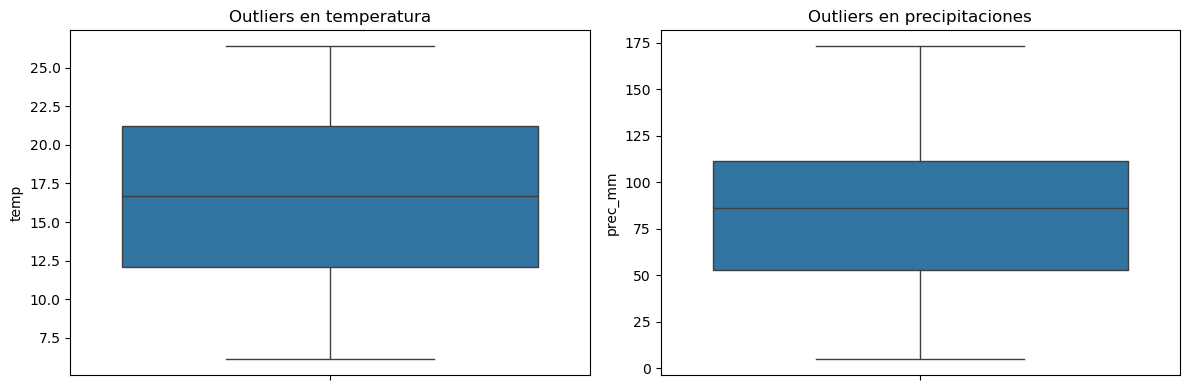

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Boxplot para temperatura
sns.boxplot(y=region_pampeana_df['temp'], ax=axes[0])
axes[0].set_title('Outliers en temperatura')

# Boxplot para humedad
sns.boxplot(y=region_pampeana_df['prec_mm'], ax=axes[1])
axes[1].set_title('Outliers en precipitaciones')

plt.tight_layout()
plt.show()

## Pregunta 18

Luego de calcular el coeficiente de correlación de Spearman entre la altura de las estaciones y la temperatura media para la región elegida, concluimos que:

- Existe una relación inversa: las estaciones a mayor altitud tienden a registrar temperaturas más bajas.
- Ambas variables (altura y temperatura) crecen o decrecen juntas.
- No hay relación aparente entre la altura de las estaciones y la temperatura media.

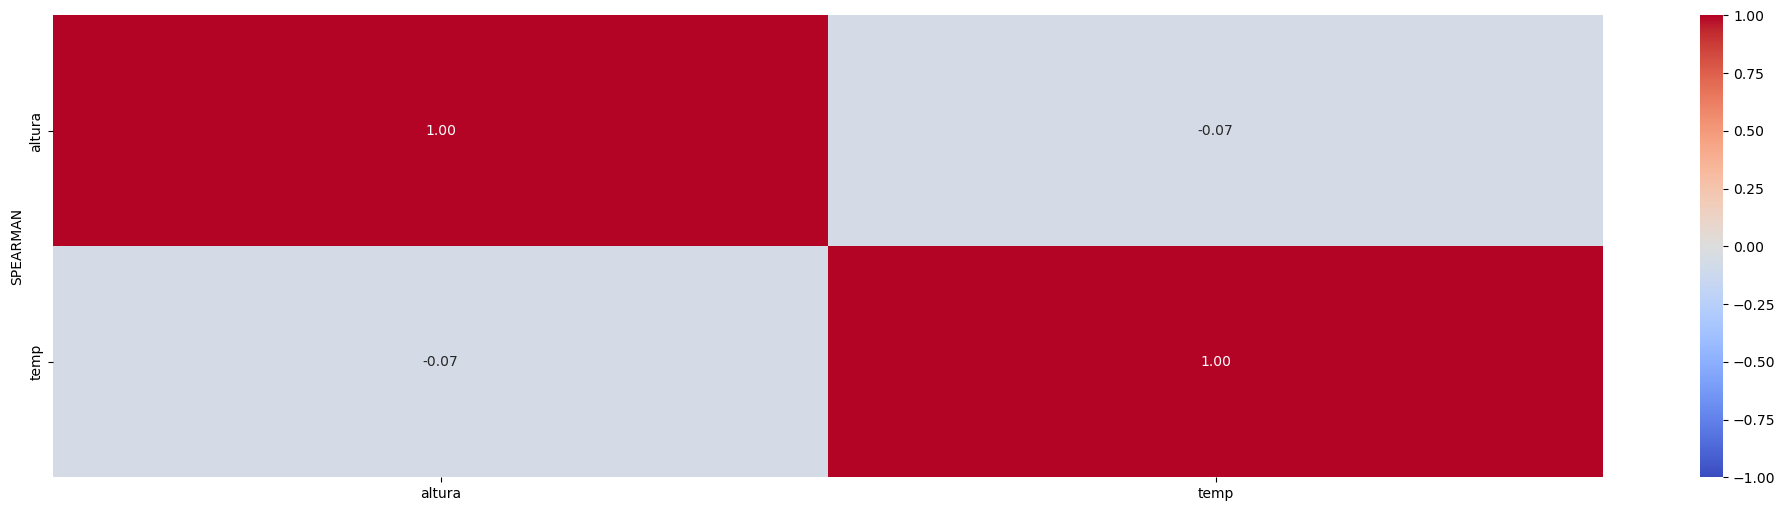

In [116]:
plt.figure(figsize=(25,6))

plt.subplot(1, 1, 1)

sns.heatmap(
    region_pampeana_df[["altura", "temp"]].corr(method='spearman', numeric_only=False),
    annot=True, 
    fmt=".2f",  
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,)
plt.ylabel('SPEARMAN')

plt.show()

## Pregunta 19

Basándote en el valor de eta cuadrado para las variables provincia y precipitación de la región elegida, ¿qué podrías afirmar?

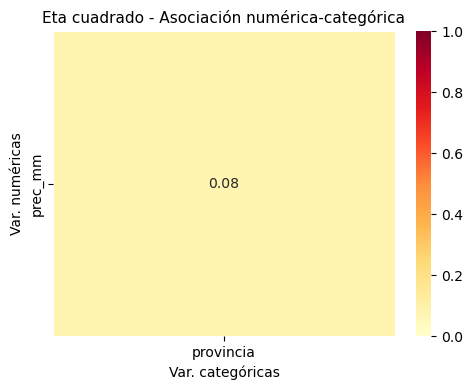

In [117]:
from scipy.stats import f_oneway

def eta_squared(continuous, categorical):
    mask       = continuous.notna() & categorical.notna()
    y, grp     = continuous[mask], categorical[mask]
    groups     = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p       = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total   = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F


num_cols = ['prec_mm']
cat_cols = ['provincia']

resultados = {}
for num_col in num_cols:
    for cat_col in cat_cols:
        eta2, p, F = eta_squared(region_pampeana_df[num_col], region_pampeana_df[cat_col])
        resultados[(num_col, cat_col)] = eta2

# Armamos la matriz de resultados
eta2_mat = pd.DataFrame(
    {cat: {num: resultados[(num, cat)] for num in num_cols} for cat in cat_cols}
)

# Dibujamos el heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Eta cuadrado - Asociación numérica-categórica", fontsize=11)
ax.set_xlabel("Var. categóricas")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

## Pregunta 20. Caracterización climática

Elegí una provincia de la región y describí brevemente su clima utilizando al menos tres variables del dataset (temperatura, precipitación, humedad, nubosidad o viento).

In [199]:
# Filtramos datos de cordoba

PROVINCIA_ELEGIDA = "CORDOBA"

cordoba_data = region_pampeana_df[region_pampeana_df['provincia'] == PROVINCIA_ELEGIDA]
cordoba_data

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
264,CORDOBA AERO,CORDOBA,495.0,87344.0,SACO,-31.283333,-64.200000,Ene,8.5,68.1,3.8,121.9,23.5,29.9,17.5,12.6
265,CORDOBA AERO,CORDOBA,495.0,87344.0,SACO,-31.283333,-64.200000,Feb,7.9,74.0,3.9,140.2,22.0,28.2,16.5,11.3
266,CORDOBA AERO,CORDOBA,495.0,87344.0,SACO,-31.283333,-64.200000,Mar,7.3,75.1,3.8,116.9,20.5,27.0,15.1,11.5
267,CORDOBA AERO,CORDOBA,495.0,87344.0,SACO,-31.283333,-64.200000,Abr,5.2,73.1,4.0,65.3,17.3,24.1,11.9,11.1
268,CORDOBA AERO,CORDOBA,495.0,87344.0,SACO,-31.283333,-64.200000,May,3.2,73.5,4.3,24.4,13.7,20.6,8.4,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.950000,-65.133333,Ago,1.0,51.5,2.7,4.7,13.0,21.6,6.5,11.3
1160,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.950000,-65.133333,Sep,2.5,48.4,2.9,19.9,16.3,24.6,9.2,11.5
1161,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.950000,-65.133333,Oct,4.3,50.8,3.2,41.9,20.1,27.9,12.8,11.3
1162,VILLA DOLORES AERO,CORDOBA,569.0,87328.0,SAOD,-31.950000,-65.133333,Nov,7.3,52.1,3.2,77.3,22.8,30.4,15.4,12.9


Evaluamos la temperatura, humedad, precipitacion y viento durante todo el año

In [200]:
month_order = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

cordoba_data.groupby("mes_txt").agg(
    temp=('temp', 'mean'),
    humedad=('humedad', 'mean'),
    prec=('prec_mm', 'mean'),
    viento=('viento', 'mean')
).reindex(month_order)

,temp,humedad,prec,viento
mes_txt,,,,
Ene,23.9375,68.3250,120.1750,11.216667
Feb,22.4250,73.6375,116.8375,9.566667
Mar,20.7750,75.1000,108.0250,9.600000
Abr,17.2625,74.8875,71.0625,9.150000
May,13.5750,76.1625,27.1375,8.816667
Jun,10.4500,73.6375,9.4750,8.733333
Jul,9.5250,68.4375,8.5625,9.550000
Ago,12.0375,60.6000,10.5250,11.383333
Sep,14.9750,59.0500,32.5875,12.433333


Evaluamos el verano

In [201]:
summer = ['Nov','Dic', 'Ene','Feb', 'Mar']

cordoba_data.groupby("mes_txt").agg(
    temp=('temp', 'mean'),
    humedad=('humedad', 'mean'),
    prec=('prec_mm', 'mean'),
    viento=('viento', 'mean')
).reindex(summer)

,temp,humedad,prec,viento
mes_txt,,,,
Nov,21.2500,61.8000,104.2375,13.216667
Dic,23.3500,63.4875,130.9250,12.566667
Ene,23.9375,68.3250,120.1750,11.216667
Feb,22.4250,73.6375,116.8375,9.566667
Mar,20.7750,75.1000,108.0250,9.600000


Evaluamos el invierno

In [202]:
winter = ['Jun','Jul', 'Ago','Sep']

cordoba_data.groupby("mes_txt").agg(
    temp_min=('temp', 'min'),
    temp_max=('temp', 'max'),
    temp_mean=('temp', 'mean'),
    humedad=('humedad', 'mean'),
    prec=('prec_mm', 'mean'),
    viento=('viento', 'mean')
).reindex(winter)

,temp_min,temp_max,temp_mean,humedad,prec,viento
mes_txt,,,,,,
Jun,9.1,11.6,10.4500,73.6375,9.4750,8.733333
Jul,8.1,10.8,9.5250,68.4375,8.5625,9.550000
Ago,10.2,13.5,12.0375,60.6000,10.5250,11.383333
Sep,13.2,16.3,14.9750,59.0500,32.5875,12.433333


Evaluamos si todo el verano es seco

In [203]:
median = region_pampeana_df[
    (region_pampeana_df['provincia'] == PROVINCIA_ELEGIDA) & 
    (region_pampeana_df['mes_txt'].isin(winter))
]['prec_mm'].median()

mode = region_pampeana_df[
    (region_pampeana_df['provincia'] == PROVINCIA_ELEGIDA) & 
    (region_pampeana_df['mes_txt'].isin(winter))
]['prec_mm'].mode()[0]

print(f"Median: {median}")
print(f"Mode: {mode}")

Median: 9.05
Mode: 6.7
